# ttbarH classification (BDT / XGBoost)

project description: Binary classification to separate Higgs signal from ttbar background using BDT/XGBoost and feature engineering.


In [1]:
# Nessesary imports 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
import uproot as ur
filename=("data_forHjTagger.root")
file = ur.open(filename)
print(file.classnames())

{'tree_event;1': 'TTree'}


In [3]:
tree = file["tree_event"]
df = tree.arrays(library="pd")
print ("File loaded with ",df.shape[0], " events ")

File loaded with  720822  events 


In [4]:
#shuffle the events, already done but just to be safe.
df = df.sample(frac=1).reset_index(drop=True)

print ("File loaded with ",df.shape[0], " events ")

File loaded with  720822  events 


In [5]:
df.columns

Index(['jet25_pt', 'jet25_btagDeepFlavB', 'jet25_btagDeepFlavB_discScore',
       'jet25_btagDeepFlavB_discScore_all5wp', 'jet25_btagDeepFlavQG',
       'jet25_btagPNetB', 'jet25_btagPNetB_discScore',
       'jet25_btagPNetB_discScore_all5wp', 'jet25_btagRobustParTAK4B',
       'jet25_btagRobustParTAK4B_discScore',
       'jet25_btagRobustParTAK4B_discScore_all5wp', 'jet25_lepdrmax',
       'jet25_lepdrmin', 'label', 'weight', 'runNumber', 'eventNumber'],
      dtype='object')

In [6]:
# target feature
df['label'].unique()

array([False,  True])

In [7]:
labels ={True: 1,False : 0}
df['labels']=df['label'].map(labels)

In [8]:
df = df.drop('label',axis=1)

In [9]:
df.head(2)

,jet25_pt,jet25_btagDeepFlavB,jet25_btagDeepFlavB_discScore,jet25_btagDeepFlavB_discScore_all5wp,jet25_btagDeepFlavQG,jet25_btagPNetB,jet25_btagPNetB_discScore,jet25_btagPNetB_discScore_all5wp,jet25_btagRobustParTAK4B,jet25_btagRobustParTAK4B_discScore,jet25_btagRobustParTAK4B_discScore_all5wp,jet25_lepdrmax,jet25_lepdrmin,weight,runNumber,eventNumber,labels
0,50.137047,0.007744,0,0,0.791992,0.006630,0,0,0.012917,0,0,2.226318,0.759402,0.000189,1,3593390,0
1,48.207527,0.016922,0,0,0.854492,0.018097,0,0,0.019409,0,0,2.916448,0.953583,0.000718,1,2671308,0


In [10]:
df['jet25_btagDeepFlavB_discScore_all5wp'].unique()

array([0, 5, 1, 2, 4, 3], dtype=int32)

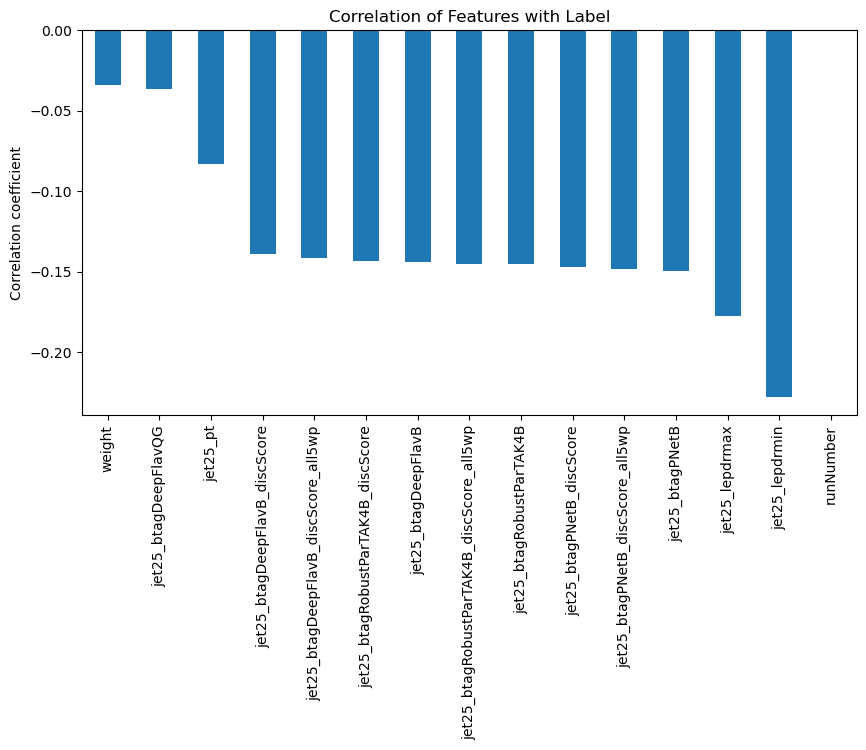

In [11]:
corr =df.corr()['labels'].drop(['labels','eventNumber'])
corr.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Correlation of Features with Label")
plt.ylabel("Correlation coefficient")
plt.show()


## ** No positive correlation with target column**

- Non-physical feature: **runNumber** , **eventNumber** is just an index or bookkeeping variable. It doesn’t encode physics information about jets, but it can leak label information if the dataset wasn’t shuffled properly.


In [12]:
df =df.drop(['runNumber', 'eventNumber'],axis=True)

In [13]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
jet25_pt,720822.0,89.164215,77.834488,25.000204,40.890828,65.394611,108.989359,1587.064209
jet25_btagDeepFlavB,720822.0,0.295011,0.393867,0.001390,0.011414,0.039398,0.660156,0.999512
jet25_btagDeepFlavB_discScore,720822.0,1.000434,1.258340,0.000000,0.000000,0.000000,2.000000,3.000000
jet25_btagDeepFlavB_discScore_all5wp,720822.0,1.383837,1.918782,0.000000,0.000000,0.000000,2.000000,5.000000
jet25_btagDeepFlavQG,720822.0,0.604069,0.219547,0.052429,0.426514,0.625977,0.798340,0.971191
jet25_btagPNetB,720822.0,0.294682,0.403051,-1.000000,0.008255,0.032959,0.698730,0.999512
jet25_btagPNetB_discScore,720822.0,1.025303,1.274257,0.000000,0.000000,0.000000,3.000000,3.000000
jet25_btagPNetB_discScore_all5wp,720822.0,1.433343,1.956774,0.000000,0.000000,0.000000,3.000000,5.000000
jet25_btagRobustParTAK4B,720822.0,0.326625,0.418115,-3.000000,0.012726,0.050659,0.864746,1.000000
jet25_btagRobustParTAK4B_discScore,720822.0,1.001354,1.277565,0.000000,0.000000,0.000000,3.000000,3.000000


In [14]:
df.head().transpose()

,0,1,2,3,4
jet25_pt,50.137047,48.207527,40.207981,245.087631,58.988480
jet25_btagDeepFlavB,0.007744,0.016922,0.011856,0.006508,0.003860
jet25_btagDeepFlavB_discScore,0.000000,0.000000,0.000000,0.000000,0.000000
jet25_btagDeepFlavB_discScore_all5wp,0.000000,0.000000,0.000000,0.000000,0.000000
jet25_btagDeepFlavQG,0.791992,0.854492,0.861816,0.915039,0.154419
jet25_btagPNetB,0.006630,0.018097,0.036285,0.004349,0.014496
jet25_btagPNetB_discScore,0.000000,0.000000,0.000000,0.000000,0.000000
jet25_btagPNetB_discScore_all5wp,0.000000,0.000000,0.000000,0.000000,0.000000
jet25_btagRobustParTAK4B,0.012917,0.019409,0.012184,0.010262,0.005684
jet25_btagRobustParTAK4B_discScore,0.000000,0.000000,0.000000,0.000000,0.000000


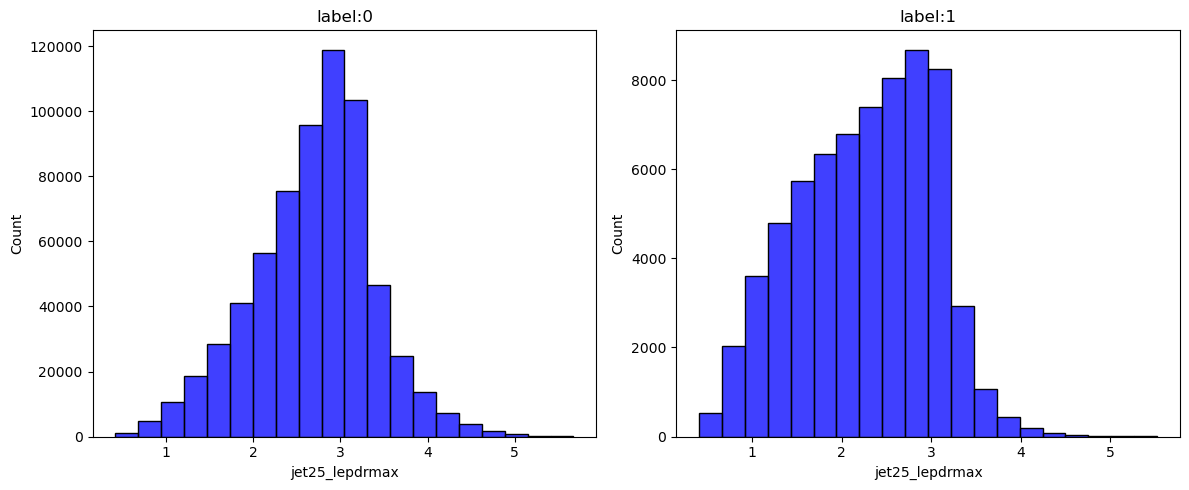

In [15]:
category=df['labels'].unique()
fig,ax=plt.subplots(1,2,figsize=(12,5),sharey=False)
for a,c in zip(ax,category):
    sns.histplot(data=df[df['labels']==c],x='jet25_lepdrmax',bins=20,color='blue',ax=a)
    a.set_title(f"label:{c}")
plt.tight_layout()
plt.show()

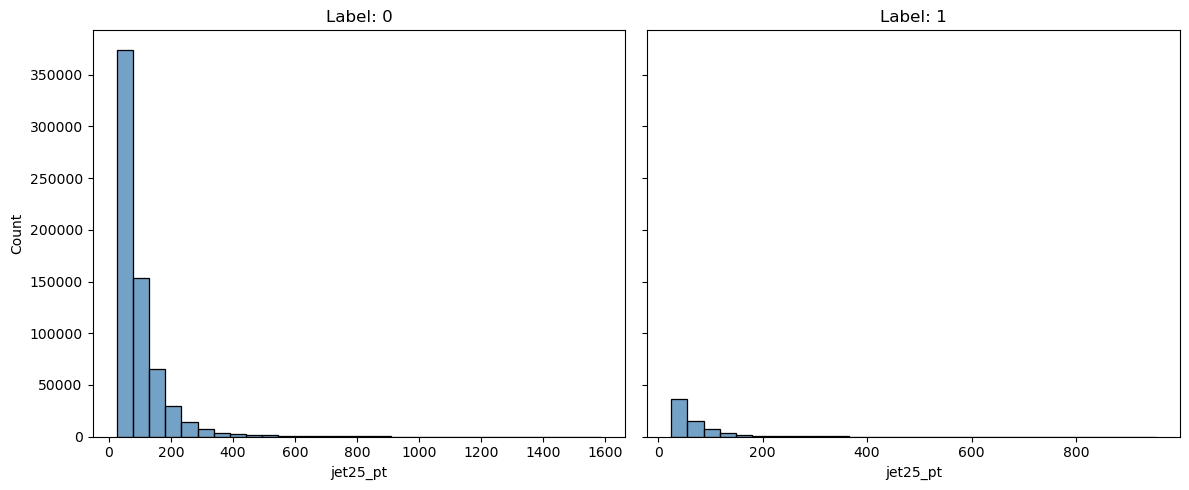

In [16]:
categories = df['labels'].unique()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, cat in zip(axes, categories):
    sns.histplot(
        data=df[df['labels'] == cat],
        x='jet25_pt',
        bins=30,
        color='steelblue',
        ax=ax
    )
    ax.set_title(f"Label: {cat}")

plt.tight_layout()
plt.show()

In [17]:
Higgs_percent = (df['labels'] == 1).mean() * 100
print(Higgs_percent)

9.288700955298257


In [18]:
# Ensure training weights are non-negative by replacing negative values with 0.
# WARNING: This adjustment may distort the statistical meaning of weights,
weights = df['weight'].apply(lambda x: x if x > 0 else 0)

In [19]:
neg_frac = (df['weight'] < 0).mean()
print(f"Fraction of negative weights: {neg_frac:.2%}")

Fraction of negative weights: 7.58%


In [20]:
X = df[[
    "jet25_lepdrmin",
    "jet25_lepdrmax",
    "jet25_pt",
    "jet25_btagDeepFlavB",
    "jet25_btagDeepFlavQG"]]
y =df['labels']

w =weights

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,stratify =y ,test_size=0.25, random_state=42
)


In [22]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train, sample_weight=w_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [23]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_score, sample_weight=w_test)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)


AUC: 0.8295509960265235


In [24]:
import numpy as np
import math

def amsasimov(s, b):
    if b <= 0 or s <= 0:
        return 0
    return math.sqrt(2 * ((s + b) * math.log(1 + s / b) - s))

In [25]:

def best_ams(y_true, y_score, weights):

    thresholds = np.linspace(0, 1, 100)
    best = 0

    for thr in thresholds:
        sel = y_score > thr

        S = weights[(y_true == 1) & sel].sum()
        B = weights[(y_true == 0) & sel].sum()

        ams = amsasimov(S, B)

        if ams > best:
            best = ams

    return best

In [26]:
y_pred = model.predict_proba(X_test)[:,1]

ams = best_ams(
    y_test.values,
    y_pred,
    w_test.values
)

print("AMS:", ams)   

AMS: 0.6249765510762377


In [28]:
from scipy.stats import ks_2samp

train_score = model.predict_proba(X_train)[:, 1]
test_score  = model.predict_proba(X_test)[:, 1]

ks = ks_2samp(train_score, test_score)

print(f"KS statistic: {ks.statistic:.4f}, p-value: {ks.pvalue:.4f}")

KS statistic: 0.0021, p-value: 0.5983


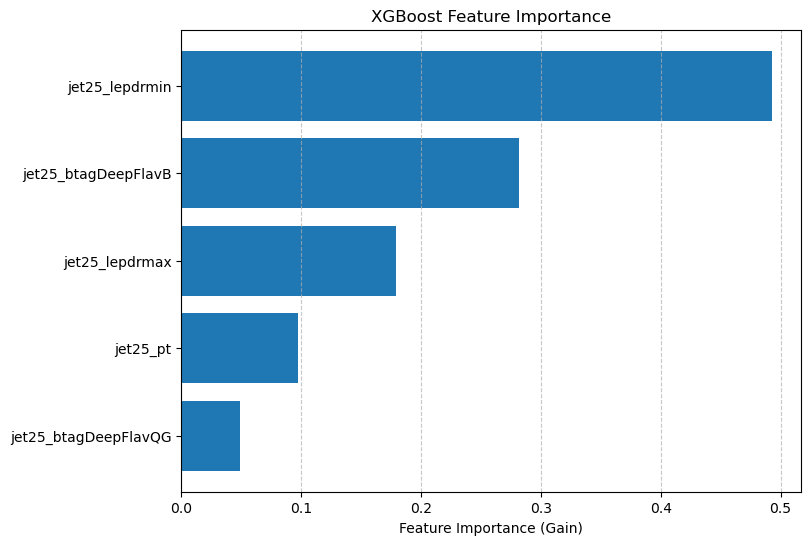

In [29]:
plt.figure(figsize=(8, 6))

# Get importance (gain type is standard for physics)
importance = model.get_booster().get_score(importance_type='gain')
# Map feature names to "Nice" names if you want
feat_names = list(importance.keys())
feat_vals = list(importance.values())

# Sort them
sorted_idx = np.argsort(feat_vals)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.barh(pos, np.array(feat_vals)[sorted_idx], align='center', color='#1f77b4')
plt.yticks(pos, np.array(feat_names)[sorted_idx])
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [30]:
train_scores = model.predict_proba(X_train)[:, 1]  # Select the second column (class 1) probabilities for all training samples


In [31]:
model.classes_ 

array([0, 1])

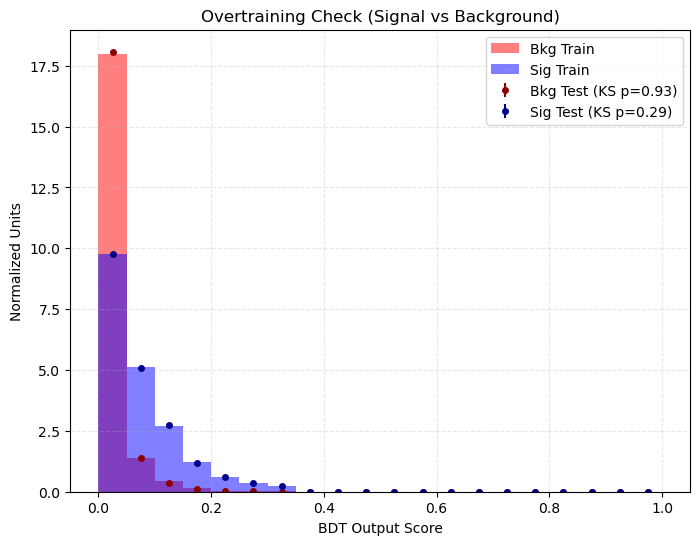

In [32]:
 # OVERTRAINING CHECK (KS TEST)
def plot_overtraining(model, X_train, y_train, X_test, y_test, w_train, w_test):
   
    train_scores = model.predict_proba(X_train)[:, 1]
    test_scores = model.predict_proba(X_test)[:, 1]

    # Separate Signal (1) and Background (0)
    sig_train = train_scores[y_train == 1]
    bkg_train = train_scores[y_train == 0]
    sig_test = test_scores[y_test == 1]
    bkg_test = test_scores[y_test == 0]
    
    # Get weights for histograms
    w_sig_train = w_train[y_train == 1]
    w_bkg_train = w_train[y_train == 0]
    w_sig_test = w_test[y_test == 1]
    w_bkg_test = w_test[y_test == 0]

    # Calculate KS Test Stats (p-value)
   
    ks_sig = ks_2samp(sig_train, sig_test)
    ks_bkg = ks_2samp(bkg_train, bkg_test)


    bins = 20
    range_bins = (0, 1)
    plt.figure(figsize=(8, 6))

  
    plt.hist(bkg_train, bins=bins, range=range_bins, weights=w_bkg_train,
             density=True, alpha=0.5, color='red', label='Bkg Train', histtype='stepfilled')
    
    # Testing: Error bars (dots)
    
    hist_bkg, bin_edges = np.histogram(bkg_test, bins=bins, range=range_bins, weights=w_bkg_test, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    plt.errorbar(bin_centers, hist_bkg, yerr=0, fmt='o', color='darkred', 
                 label=f'Bkg Test (KS p={ks_bkg.pvalue:.2f})', markersize=4)

    
    plt.hist(sig_train, bins=bins, range=range_bins, weights=w_sig_train,
             density=True, alpha=0.5, color='blue', label='Sig Train', histtype='stepfilled')
    
    # Testing: Error bars (dots)
    hist_sig, _ = np.histogram(sig_test, bins=bins, range=range_bins, weights=w_sig_test, density=True)
    plt.errorbar(bin_centers, hist_sig, yerr=0, fmt='o', color='darkblue', 
                 label=f'Sig Test (KS p={ks_sig.pvalue:.2f})', markersize=4)


    plt.xlabel('BDT Output Score')
    plt.ylabel('Normalized Units')
    plt.title('Overtraining Check (Signal vs Background)')
    plt.legend(loc='best')
    plt.grid(linestyle='--', alpha=0.3)
    plt.show()
plot_overtraining(model, X_train, y_train, X_test, y_test, w_train, w_test)

### Overtraining Check and Class Imbalance

The plot above shows the distribution of the **BDT output score** for signal and background events in both the **training** and **test** datasets.  
To check for possible **overtraining**, the score distributions of the training and test samples are compared using the **Kolmogorov–Smirnov (KS) test**.

- If the model generalizes well, the training and test distributions should be statistically consistent.

The KS test p-values shown in the legend quantify this agreement. While the agreement is reasonably acceptable, the plot reveals that most events accumulate at **low BDT scores**, indicating that the classifier is dominated by **background-like events**.

This behavior is primarily due to the **class imbalance in the dataset**, where background events significantly outnumber signal events. In such situations, the classifier tends to favor the majority class, which can degrade the model's ability to correctly identify signal events.

To mitigate this issue, we introduce **class weighting** using the `scale_pos_weight` parameter in the boosting algorithm. This parameter increases the effective importance of the minority class (signal) during training, helping the model learn a more balanced decision boundary.

In the next section, we retrain the model using this weighting strategy to improve signal sensitivity.

## Aiming for better 

In [33]:
df.loc[df['labels']==0,'weight'].sum()

np.float64(913.3838528046125)

In [34]:
# Calculate the ratio of Background to Signal

sum_w_pos = df.loc[df['labels'] == 1, 'weight'].sum()
sum_w_neg = df.loc[df['labels'] == 0, 'weight'].sum()

scale_ratio = sum_w_neg / sum_w_pos
print(f"Scale Ratio: {scale_ratio:.2f}") 



Scale Ratio: 32.77


In [35]:

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,stratify=y, test_size=0.25, random_state=42
)


In [36]:
model1 = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight=scale_ratio,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model1.fit(X_train, y_train, sample_weight=w_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


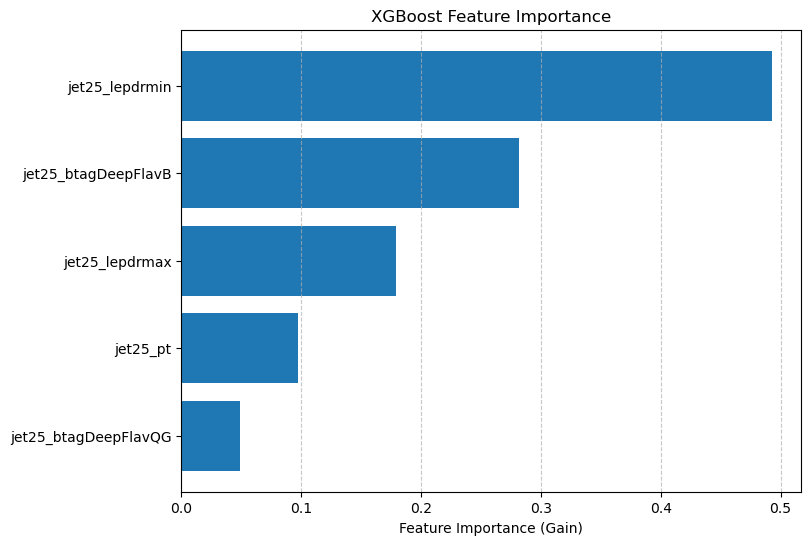

In [37]:
plt.figure(figsize=(8, 6))


importance = model.get_booster().get_score(importance_type='gain')

feat_names = list(importance.keys())
feat_vals = list(importance.values())
sorted_idx = np.argsort(feat_vals)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.barh(pos, np.array(feat_vals)[sorted_idx], align='center', color='#1f77b4')
plt.yticks(pos, np.array(feat_names)[sorted_idx])
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

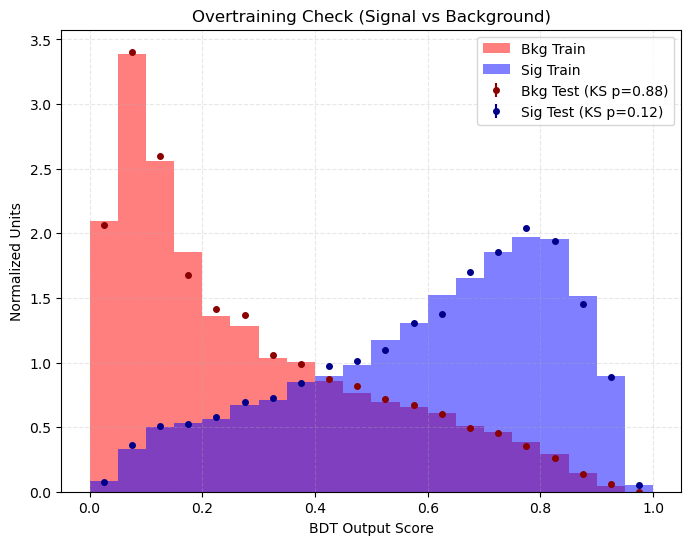

In [38]:
 # OVERTRAINING CHECK (KS TEST)
plot_overtraining(model1, X_train, y_train, X_test, y_test, w_train, w_test) # for model 1

In [39]:
# Significance Score 
y_pred = model1.predict_proba(X_test)[:,1]

ams = best_ams(
    y_test.values,
    y_pred,
    w_test.values
)

print("AMS:", ams)

AMS: 0.6391805412009129


Model AUC Score: 0.830


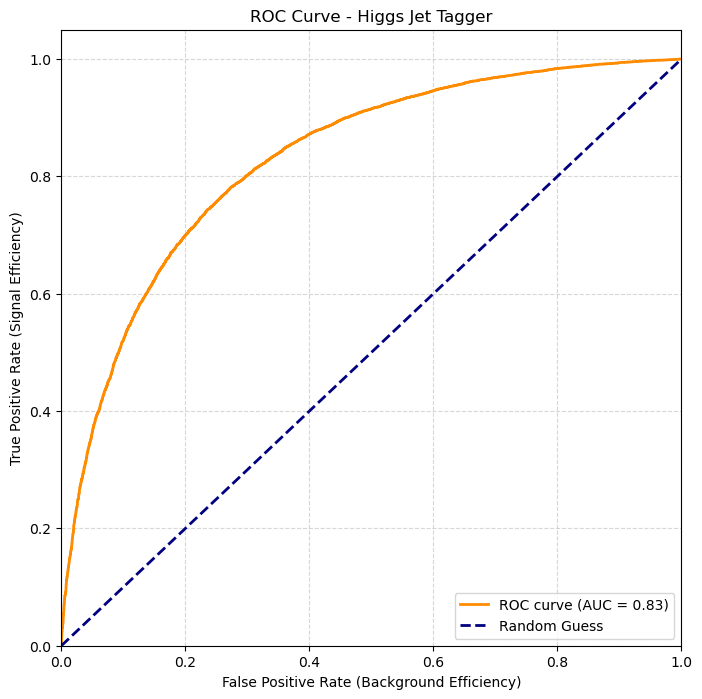

In [40]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score, sample_weight=w_test)
# Calculate the AUC (Area Under the Curve) score
roc_auc = auc(fpr, tpr)
print(f"Model AUC Score: {roc_auc:.3f}")
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Efficiency)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('ROC Curve - Higgs Jet Tagger')
plt.legend(loc="lower right")
plt.grid(linestyle='--', alpha=0.5)
plt.show()

In [41]:
train_scores = model.predict_proba(X_train)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]
sig_trains =train_scores[y_train==1]
sig_test = test_scores[y_test == 1]
bkg_test = test_scores[y_test == 0]

ks_statistic, p_value = ks_2samp(sig_trains,sig_test)

print(f"Kolmogorov–Smirnov Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. The two samples come from different distributions.")
else:
    print("Fail to reject the null hypothesis. There is not enough evidence to suggest different distributions.")

Kolmogorov–Smirnov Statistic: 0.00875566379336018
P-value: 0.2892208249723043
Fail to reject the null hypothesis. There is not enough evidence to suggest different distributions.


## Using More Features

To improve the classifier performance, we extend the input feature set by including additional kinematic and tagging variables. These extra features may provide more discriminating power between signal and background events.

In [42]:
### Checking Feature Correlations

# We also examine the correlation between input features to identify highly correlated variables, which may introduce redundant information in the model.

<Axes: >

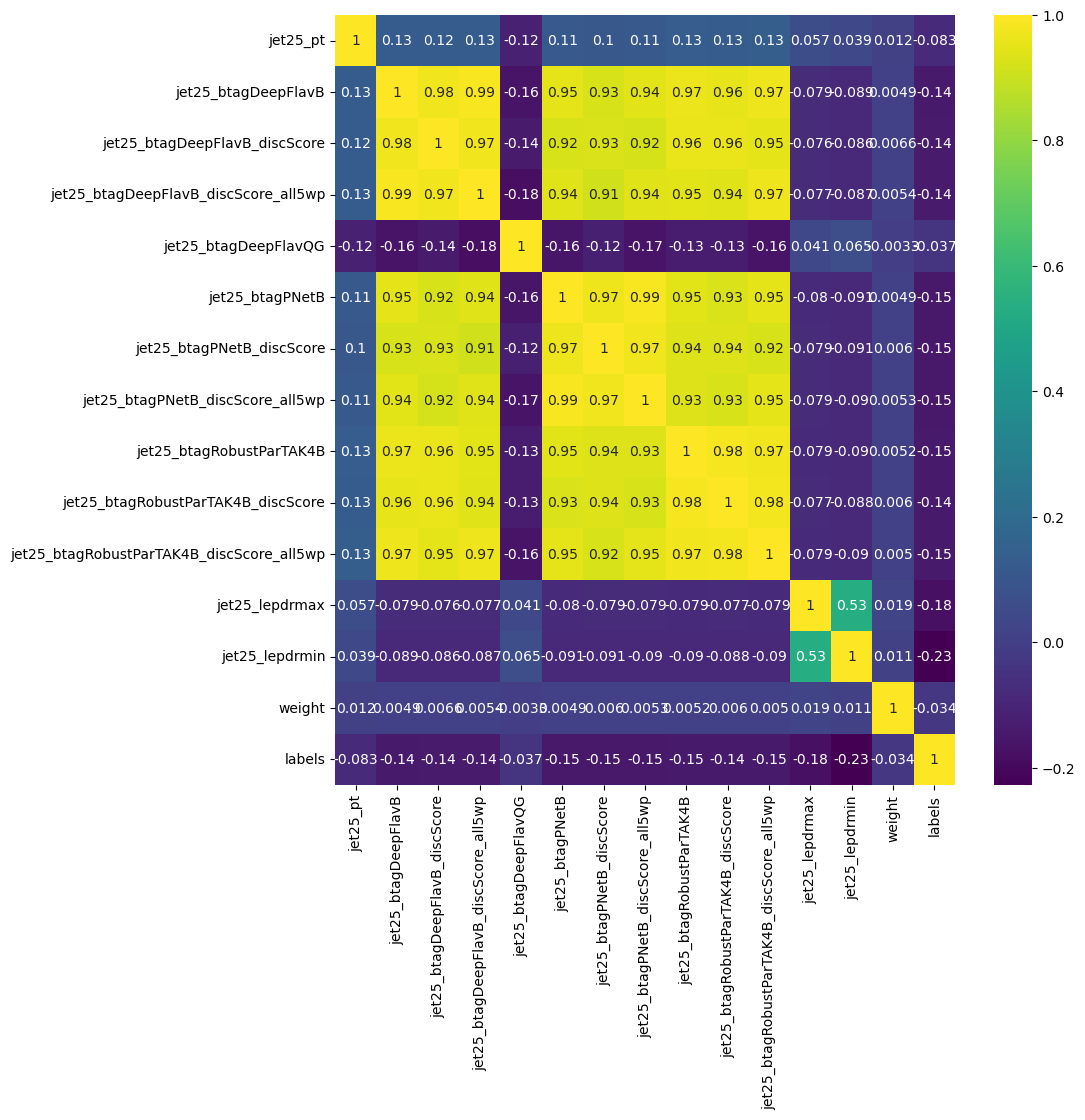

In [43]:
plt.figure(figsize=(10,10))
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True,cmap='viridis')

As expected, several input variables show **strong correlations** with each other, particularly among the different **b-tagging discriminators**, since they are derived from related tagging algorithms.

In [44]:
w_pos=abs(df['weight'])  # Usng absolute weights this time 



In [45]:
data =df.drop(['weight','labels','jet25_btagRobustParTAK4B_discScore_all5wp','jet25_btagDeepFlavB_discScore'],axis=1)

target = df["labels"]


print ("Df shape of dataset to be used :",data.shape)

display(target.head())
display(weights.head())


Df shape of dataset to be used : (720822, 11)


0    0
1    0
2    0
3    0
4    0
Name: labels, dtype: int64

0    0.000189
1    0.000718
2    0.000100
3    0.001032
4    0.000196
Name: weight, dtype: float64

In [46]:
X_train1, X_test1, y_train1, y_test1,w_train1,w_test1 = train_test_split(
    data, target,weights, test_size=0.2, random_state=42, stratify=y
)


In [47]:
from xgboost import XGBClassifier

model2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model2.fit(X_train1, y_train1, sample_weight=w_train1)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


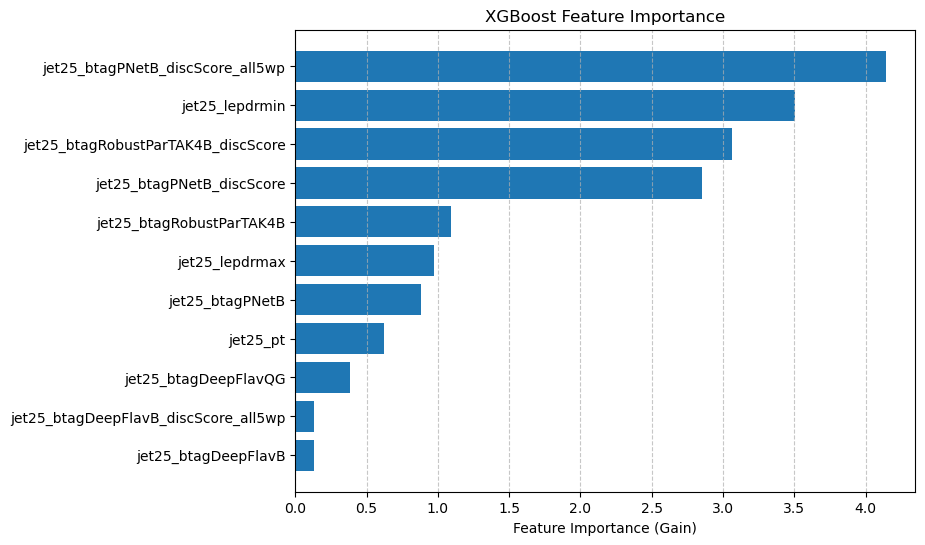

In [48]:
plt.figure(figsize=(8, 6))

importance = model2.get_booster().get_score(importance_type='gain')

feat_names = list(importance.keys())
feat_vals = list(importance.values())
sorted_idx = np.argsort(feat_vals)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.barh(pos, np.array(feat_vals)[sorted_idx], align='center', color='#1f77b4')
plt.yticks(pos, np.array(feat_names)[sorted_idx])
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

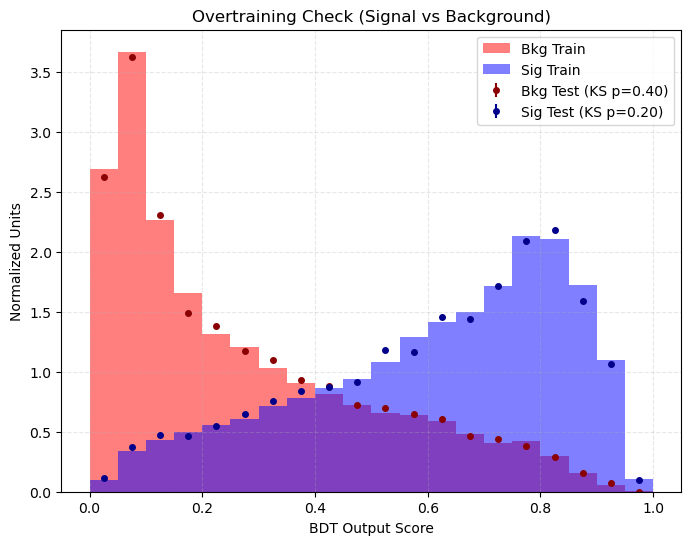

In [49]:
plot_overtraining(model2, X_train1, y_train1, X_test1, y_test1, w_train1, w_test1)

Model AUC Score: 0.834


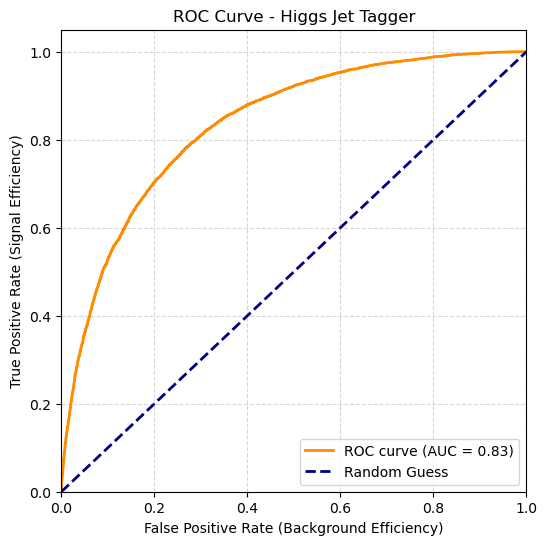

In [50]:
y_score = model1.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score, sample_weight=w_test)
# Calculate the AUC (Area Under the Curve) score
roc_auc = auc(fpr, tpr)
print(f"Model AUC Score: {roc_auc:.3f}")
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Efficiency)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('ROC Curve - Higgs Jet Tagger')
plt.legend(loc="lower right")
plt.grid(linestyle='--', alpha=0.5)
plt.show()

In [55]:
# save best model
import joblib

# Save with joblib
joblib.dump(model, "xgb_model.pkl")


['xgb_model.pkl']

In [56]:
# load back
loaded_model = joblib.load("xgb_model.pkl")